# Connectors PSD reproduction (BTD/BTC)

This notebook reproduces the current **Connectors PSD backend behaviour** (`/psd/infer-model` and `/psd/evaluate`) and provides a harness for comparing against measured fragmentation curves (e.g. FRAGTrack / image analysis / sieve).

Defaults used in the BtC frontend:
- CSS = **130 mm**
- Target F80 = **130 mm**
- Target P80 = **80 mm**

> Notes
> - Percentiles are computed using the **bounded inverse-CDF** logic used in the Connectors backend.
> - Two measured formats are supported:
>   - `cdf_pairs`: sizes + cumulative passing fraction
>   - `hist_bins`: bin edges + mass fraction per bin


In [1]:
# --- Imports
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Callable, Dict, List, Literal, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json


In [2]:
# --- Canonical CDFs (ported from src/utils/psd.py)

def clamp01(v: float) -> float:
	if v < 0.0: return 0.0
	if v > 1.0: return 1.0
	return v

def as_cdf(fn: Callable[[float], float]) -> Callable[[float], float]:
	"""Wrap a function to enforce finite, clamped [0,1] output."""
	def F(x: float) -> float:
		try:
			y = float(fn(float(x)))
		except Exception:
			return 0.0
		if not math.isfinite(y):
			return 0.0
		return clamp01(y)
	return F

def cdf_swebrec_xmax(x_mm: float, x50_mm: float, b: float, xmax_mm: float) -> float:
	if x_mm <= 0 or x50_mm <= 0 or b <= 0 or xmax_mm <= 0:
		return 0.0
	if x_mm >= xmax_mm:
		return 1.0
	if not (x50_mm < xmax_mm):
		return 0.0

	den = math.log(xmax_mm / x50_mm)
	if den <= 0:
		return 0.0

	num = math.log(xmax_mm / x_mm)
	if num <= 0:
		return 1.0

	ratio = num / den
	val = 1.0 / (1.0 + (ratio**b))
	return clamp01(val)

def cdf_swebrec_ab(x_mm: float, x50_mm: float, b: float, a: float) -> float:
	if x_mm <= 0 or x50_mm <= 0 or b <= 0 or a <= 0:
		return 0.0
	ratio = x_mm / x50_mm
	inner = 1.0 + (ratio ** (-b))
	val = 1.0 / (inner**a)
	return clamp01(val)

def cdf_rr_weibull(x_mm: float, xc_mm: float, n: float) -> float:
	if x_mm <= 0 or xc_mm <= 0 or n <= 0:
		return 0.0
	val = 1.0 - math.exp(-((x_mm / xc_mm) ** n))
	return clamp01(val)

def cdf_lognormal(x_mm: float, mu: float, sigma: float) -> float:
	if x_mm <= 0 or sigma <= 0:
		return 0.0
	z = (math.log(x_mm) - mu) / (sigma * math.sqrt(2.0))
	val = 0.5 * (1.0 + math.erf(z))
	return clamp01(val)


In [3]:
# --- Types mirroring the backend v2 schemas (psd_routes.py)

PsdContext = Literal["dig", "crush"]
PsdMode = Literal["modelled", "measured"]
PsdModelType = Literal["swebrec_xmax", "swebrec_ab", "rr", "lognormal"]

@dataclass
class DesignInputs:
		burden_m: float
		spacing_m: float
		bench_height_m: float
		hole_diameter_mm: float
		stemming_m: float
		subdrill_m: float
		ucs_mpa: float
		explosive_density_gcc: Optional[float] = None
		explosive_energy_mjkg: Optional[float] = None
		pattern: Optional[Literal["staggered", "rectangular"]] = None
		blast_type: Optional[str] = None

@dataclass
class PsdParam:
		model: PsdModelType
		params: Dict[str, float]

@dataclass
class PsdDiscreteCdfPairs:
		type: Literal["cdf_pairs"]
		x_mm: List[float]
		passing_frac: List[float]  # 0..1

@dataclass
class PsdDiscreteHistBins:
		type: Literal["hist_bins"]
		bin_edges_mm: List[float]  # length n+1
		frac_per_bin: List[float]  # length n, sums to ~1

PsdDiscrete = Union[PsdDiscreteCdfPairs, PsdDiscreteHistBins]

DEFAULT_X_GRID_MM = [
	0.5, 0.7, 1, 1.5, 2, 3, 4, 6, 8, 10,
	15, 20, 30, 40, 60, 80, 100, 150, 200, 300,
	400, 600, 800, 1000, 1500, 2000,
]

DEFAULT_X_GRID_MM_CRUSH = [
	0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.5, 0.75, 1,
	1.5, 2, 3, 4, 6, 8, 10, 15, 20, 30, 50, 75, 100,
	150, 200, 300, 400, 600, 800, 1000, 1500, 2000,
	2500, 3000, 3500, 4000, 4500, 5000,
]

DEFAULT_SAMPLE_SIZES_MM = [
	10, 25, 50, 80, 100, 150, 200, 300, 400, 600, 800,
	1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000,
]


In [4]:
# --- Backend helper functions (ported from psd_routes.py)

def _default_log_grid_mm(lo: float = 0.5, hi: float = 2000.0, n: int = 70) -> List[float]:
	return [lo * (hi / lo) ** (i / (n - 1)) for i in range(n)]

def _clamp(v: float, lo: float, hi: float) -> float:
	return max(lo, min(hi, float(v)))

def _powder_factor_kg_m3(d: DesignInputs) -> Optional[float]:
	if d.explosive_density_gcc is None:
		return None

	rho_kg_m3 = float(d.explosive_density_gcc) * 1000.0
	if not (rho_kg_m3 > 0 and d.hole_diameter_mm > 0):
		return None

	burden = float(d.burden_m)
	spacing = float(d.spacing_m)
	bench_h = float(d.bench_height_m)
	stemming = max(0.0, float(d.stemming_m))
	subdrill = max(0.0, float(d.subdrill_m))

	if not (burden > 0 and spacing > 0 and bench_h > 0):
		return None

	hole_len = bench_h + subdrill
	charge_len = max(0.0, hole_len - stemming)
	if charge_len <= 0:
		return 0.0

	d_m = float(d.hole_diameter_mm) / 1000.0
	r = d_m / 2.0
	charge_vol_m3 = math.pi * r * r * charge_len
	charge_mass_kg = charge_vol_m3 * rho_kg_m3

	if d.pattern == "staggered":
		area_per_hole = burden * spacing * (math.sqrt(3.0) / 2.0)
	else:
		area_per_hole = burden * spacing

	rock_vol_m3 = area_per_hole * bench_h
	if rock_vol_m3 <= 0:
		return None

	return charge_mass_kg / rock_vol_m3

def _energy_factor_mj_m3(d: DesignInputs, pf_kg_m3: Optional[float]) -> Optional[float]:
	if pf_kg_m3 is None:
		return None
	if d.explosive_energy_mjkg is None:
		return None
	e = float(d.explosive_energy_mjkg)
	if not (e > 0 and math.isfinite(e)):
		return None
	return float(pf_kg_m3) * e

def _cdf_from_model(model: PsdParam) -> Callable[[float], float]:
	t = model.model
	p = model.params or {}

	def g(key: str, default: float) -> float:
		v = p.get(key, default)
		try:
			return float(v)
		except Exception:
			return float(default)

	if t == "swebrec_xmax":
		x50 = g("x50_mm", 65.0)
		b = g("b", 2.2)
		xmax = g("xmax_mm", 5000.0)
		return as_cdf(lambda x: cdf_swebrec_xmax(x, x50, b, xmax))

	if t == "swebrec_ab":
		x50 = g("x50_mm", 65.0)
		b = g("b", 2.2)
		a = g("a", 1.0)
		return as_cdf(lambda x: cdf_swebrec_ab(x, x50, b, a))

	if t == "rr":
		xc = g("xc_mm", 120.0)
		n = g("n", 1.6)
		return as_cdf(lambda x: cdf_rr_weibull(x, xc, n))

	if t == "lognormal":
		sigma = g("sigma", 0.5)
		mu = p.get("mu", None)
		if mu is None:
			x50 = g("x50_mm", 65.0)
			mu = math.log(max(x50, 1e-12))
		else:
			mu = float(mu)
		return as_cdf(lambda x: cdf_lognormal(x, float(mu), sigma))

	return as_cdf(lambda x: 0.0)

def _cdf_from_measured(measured: PsdDiscrete) -> Callable[[float], float]:
	if measured.type == "cdf_pairs":
		xs = [float(x) for x in measured.x_mm]
		ys = [float(y) for y in measured.passing_frac]
		pairs = sorted((x, y) for x, y in zip(xs, ys) if x > 0 and 0 <= y <= 1)
		if not pairs:
			return as_cdf(lambda x: 0.0)

		def F(x: float) -> float:
			if x <= pairs[0][0]:
				return 0.0
			for i in range(1, len(pairs)):
				x0, y0 = pairs[i - 1]
				x1, y1 = pairs[i]
				if x <= x1:
					if x1 == x0:
						return y1
					t = (x - x0) / (x1 - x0)
					return y0 + t * (y1 - y0)
			return 1.0

		return as_cdf(F)

	# hist_bins
	edges = [float(x) for x in measured.bin_edges_mm]
	fracs = [float(w) for w in measured.frac_per_bin]
	if len(edges) < 2 or len(fracs) != len(edges) - 1:
		return as_cdf(lambda x: 0.0)

	cum = []
	s = 0.0
	for i, w in enumerate(fracs):
		s += max(0.0, w)
		cum.append((edges[i + 1], s))

	total = cum[-1][1] if cum else 0.0
	if total > 0:
		cum = [(x, max(0.0, min(1.0, y / total))) for x, y in cum]

	def F(x: float) -> float:
		if x <= cum[0][0]:
			return 0.0
		for i in range(1, len(cum)):
			x0, y0 = cum[i - 1]
			x1, y1 = cum[i]
			if x <= x1:
				if x1 == x0:
					return y1
				t = (x - x0) / (x1 - x0)
				return y0 + t * (y1 - y0)
		return 1.0

	return as_cdf(F)

def _quantile(F: Callable[[float], float], p: float, lo: float, hi: float, max_iter: int = 60) -> float:
	p = float(p)
	if p <= 0: return 0.0
	if p >= 1: return float(hi)

	lo = float(lo); hi = float(hi)
	for _ in range(max_iter):
		mid = 0.5 * (lo + hi)
		if F(mid) < p:
			lo = mid
		else:
			hi = mid
	return 0.5 * (lo + hi)


In [ ]:
# --- Infer Swebrec(xmax) (ported from /psd/infer-model)

def infer_swebrec_xmax(d: DesignInputs, context: PsdContext) -> Tuple[PsdParam, Dict]:
	pf = _powder_factor_kg_m3(d)
	ef = _energy_factor_mj_m3(d, pf)

	x50_ref = 65.0
	b_ref = 4.3
	xmax_ref = 5000.0

	burden = float(d.burden_m)
	spacing = float(d.spacing_m)
	ucs = float(d.ucs_mpa)

	br = burden / 7.0 if burden > 0 else 1.0
	sr = spacing / 8.0 if spacing > 0 else 1.0
	ur = ucs / 110.0 if ucs > 0 else 1.0
	

	ef_ref = 2.5
	er = (ef / ef_ref) if (ef is not None and ef > 0) else 1.0

	x50 = x50_ref * (br**0.45) * (sr**0.25) * (ur**0.40) * (er**-0.65)
	b = b_ref * (er**0.22) * (ur**-0.12)
	xmax = max(xmax_ref * (ur**0.12) * (er**-0.08), 22.0 * x50)

	if context == "crush":
		x50 = _clamp(x50, 20.0, 250.0)
		b = _clamp(b, 1.3, 3.5)
		xmax = _clamp(xmax, 300.0, 2500.0)
	else:
		x50 = _clamp(x50, 10.0, 600.0)
		b = _clamp(b, 1.2, 8.0)
		xmax = _clamp(xmax, 200.0, 10000.0)

	model = PsdParam(
		model="swebrec_xmax",
		params={"x50_mm": float(round(x50, 3)), "b": float(round(b, 3)), "xmax_mm": float(round(xmax, 3))},
	)

	debug = {
		"pf_kg_m3": None if pf is None else float(round(pf, 4)),
		"ef_mj_m3": None if ef is None else float(round(ef, 2)),
		"anchors": {"x50_ref": x50_ref, "b_ref": b_ref, "xmax_ref": xmax_ref, "ef_ref": ef_ref},
		"ratios": {"br": br, "sr": sr, "ur": ur, "er": er},
	}
	return model, debug

def sanitise_swebrec_xmax_params(params: Dict, context: PsdContext) -> Tuple[Dict, bool]:
	if not isinstance(params, dict):
		return {}, False

	changed = False
	x50 = float(params.get("x50_mm", 0) or 0)
	b = float(params.get("b", 0) or 0)
	xmax = float(params.get("xmax_mm", 0) or 0)

	if context == "crush":
		x50_lo, x50_hi = 20.0, 250.0
		b_lo, b_hi = 1.3, 3.5
		xmax_lo, xmax_hi = 300.0, 2500.0
		default_x50, default_b, default_xmax = 65.0, 2.2, 1800.0
	else:
		x50_lo, x50_hi = 10.0, 600.0
		b_lo, b_hi = 1.2, 8.0
		xmax_lo, xmax_hi = 200.0, 10000.0
		default_x50, default_b, default_xmax = 65.0, 2.2, 5000.0

	def clamp(v: float, lo: float, hi: float) -> float:
		return max(lo, min(hi, v))

	x50_c = clamp(x50 if x50 > 0 else default_x50, x50_lo, x50_hi)
	b_c = clamp(b if b > 0 else default_b, b_lo, b_hi)
	xmax_c = clamp(xmax if xmax > 0 else default_xmax, xmax_lo, xmax_hi)

	xmax_min = 3.0 * x50_c
	if xmax_c < xmax_min:
		xmax_c = clamp(xmax_min, xmax_lo, xmax_hi)

	if (x50_c != x50) or (b_c != b) or (xmax_c != xmax):
		changed = True

	out = dict(params)
	out["x50_mm"] = x50_c
	out["b"] = b_c
	out["xmax_mm"] = xmax_c
	return out, changed


In [6]:
# --- Evaluate PSD (ported from /psd/evaluate)

def evaluate_psd(
	*,
	context: PsdContext,
	design: DesignInputs,
	mode: PsdMode,
	model: Optional[PsdParam] = None,
	measured: Optional[PsdDiscrete] = None,
	x_grid_mm: Optional[List[float]] = None,
	sample_sizes_mm: Optional[List[float]] = None,
) -> Dict:
	used_source: Optional[str] = None
	resolved_model: Optional[str] = None
	resolved_params: Optional[Dict[str, float]] = None
	sanitised: bool = False
	xmax_hint = 2000.0
	input_params: Dict[str, float] = {}

	if mode == "modelled" and model is not None:
		used_source = "analytic"
		resolved_model = model.model

		input_params = {k: float(v) for k, v in (model.params or {}).items() if v is not None}
		resolved_params = dict(input_params)

		if model.model == "swebrec_xmax":
			new_params, sanitised = sanitise_swebrec_xmax_params(input_params, context)
			model = PsdParam(model="swebrec_xmax", params=new_params)
			resolved_params = dict(new_params)

		F = _cdf_from_model(model)
		xmax_hint = float(model.params.get("xmax_mm", 2000.0)) if model.model == "swebrec_xmax" else 2000.0

	elif mode == "measured" and measured is not None:
		F = _cdf_from_measured(measured)
		used_source = measured.type
		xmax_hint = 2000.0

	else:
		F = as_cdf(lambda x: 0.0)
		used_source = "none"
		xmax_hint = 2000.0

	xs = x_grid_mm or _default_log_grid_mm(0.5, max(620.0, xmax_hint), 70)
	ys = [float(F(x)) * 100.0 for x in xs]

	wanted = [0.2, 0.5, 0.8, 0.95, 0.98]
	pct: Dict[str, Optional[float]] = {}
	grid_max_mm = max(xs) if xs else 2000.0

	hi_for_estimate_mm = min(max(grid_max_mm, float(xmax_hint)), 10000.0)
	p98_est_mm = float(_quantile(F, 0.98, lo=0.1, hi=hi_for_estimate_mm))

	hi_quantile_mm = min(grid_max_mm, max(float(xmax_hint), p98_est_mm * 1.05))
	hi_quantile_mm = float(min(max(10.0, hi_quantile_mm), 10000.0))

	for p in wanted:
		key = f"p{int(round(p * 100))}"
		pct[key] = float(_quantile(F, p, lo=0.1, hi=hi_quantile_mm))

	samples = None
	if sample_sizes_mm:
		samples = {str(float(s)): float(F(float(s)) * 100.0) for s in sample_sizes_mm}

	return {
		"series": [{"name": "Predicted", "x": [float(x) for x in xs], "y": ys}],
		"percentiles_mm": pct,
		"samples_pct_passing": samples,
		"debug": {
			"used_source": used_source,
			"resolved_model": resolved_model,
			"input_params": input_params,
			"resolved_params": resolved_params,
			"params_sanitised": sanitised,
			"grid_max_mm": grid_max_mm,
			"xmax_hint_mm": float(xmax_hint),
			"hi_quantile_mm": hi_quantile_mm,
			"p98_est_mm": p98_est_mm,
			"hi_for_estimate_mm": hi_for_estimate_mm,
			"hi_quantile_mm_used": hi_quantile_mm,
		},
	}


In [7]:
# --- Plotting utilities (UI-equivalent semantics)

FOCUS_OPTIONS = {
	"auto": 1.0,
	"full": None,
	"p0_5": 0.5,
	"p2": 2.0,
	"p5": 5.0,
}

def _x_at_passing_pct(series: Dict, p_pct: float) -> Optional[float]:
	xs = np.asarray(series["x"], dtype=float)
	ys = np.asarray(series["y"], dtype=float)
	if len(xs) < 2 or len(ys) < 2:
		return None
	for i in range(1, len(xs)):
		x0, x1 = xs[i-1], xs[i]
		y0, y1 = ys[i-1], ys[i]
		if y1 == y0:
			continue
		lo, hi = (y0, y1) if y0 <= y1 else (y1, y0)
		if p_pct >= lo and p_pct <= hi:
			t = (p_pct - y0) / (y1 - y0)
			x = x0 + t * (x1 - x0)
			return float(x) if math.isfinite(x) else None
	return None

def plot_psd(
	result: Dict,
	*,
	title: str = "PSD",
	css_mm: Optional[float] = None,
	target_p80_mm: Optional[float] = None,
	feed_p80_mm: Optional[float] = None,
	product_p80_mm: Optional[float] = None,
	x_max_cap_mm: Optional[float] = None,
	dig_window_mm: Optional[Dict[str, float]] = None,
	dig_window_label: Optional[str] = None,
	markers: Optional[Dict[str, bool]] = None,
	focus_mode_id: str = "auto",
):
	series = result["series"]
	if not series:
		raise ValueError("No series to plot.")
	s = series[0]

	xs = np.asarray(s["x"], dtype=float)
	ys = np.asarray(s["y"], dtype=float)

	# Focus trimming (as per PsdCurvesPlot)
	passing_pct = FOCUS_OPTIONS.get(focus_mode_id, 1.0)
	if passing_pct is not None:
		x_start = _x_at_passing_pct(s, float(passing_pct))
		if x_start is not None:
			mask = xs >= x_start
			xs, ys = xs[mask], ys[mask]

	if x_max_cap_mm is not None:
		mask = xs <= float(x_max_cap_mm)
		xs, ys = xs[mask], ys[mask]

	fig, ax = plt.subplots(figsize=(10, 5))
	ax.plot(xs, ys, linewidth=2, label=s.get("name", "Series"))

	ax.set_xscale("log")
	ax.set_ylim(0, 100)
	ax.set_xlabel("Size (mm)")
	ax.set_ylabel("% passing")
	ax.set_title(title)
	ax.grid(True, which="both", linestyle="--", alpha=0.3)

	# Reference lines
	def vline(x, label, style="-", alpha=0.9):
		if x is None: return
		ax.axvline(float(x), linestyle=style, alpha=alpha)
		ax.text(float(x), 98, label, rotation=90, va="top", ha="right", fontsize=9)

	vline(css_mm, "CSS", style="--", alpha=0.7)
	vline(target_p80_mm, "Target P80", style="--", alpha=0.7)
	vline(feed_p80_mm, "Feed P80", style=":", alpha=0.9)
	vline(product_p80_mm, "Product P80", style=":", alpha=0.9)

	# Dig window shading
	if dig_window_mm and dig_window_mm.get("min") and dig_window_mm.get("max"):
		ax.axvspan(float(dig_window_mm["min"]), float(dig_window_mm["max"]), alpha=0.12)
		if dig_window_label:
			ax.text(float(dig_window_mm["min"]), 5, dig_window_label, fontsize=9, va="bottom")

	# Markers p50/p80/p95 based on computed percentiles
	pct = result.get("percentiles_mm") or {}
	mk = markers or {"p50": True, "p80": True, "p95": True}
	for key, ylab in [("p50", "P50"), ("p80", "P80"), ("p95", "P95")]:
		if not mk.get(key, False):
			continue
		x = pct.get(key)
		if x is not None and math.isfinite(float(x)):
			ax.scatter([float(x)], [float({"p50":50,"p80":80,"p95":95}[key])], s=40)
			ax.text(float(x), float({"p50":50,"p80":80,"p95":95}[key])+2, ylab, fontsize=9, ha="left")

	ax.legend(loc="lower right")
	plt.show()


In [8]:
# --- Defaults used in the apps (as per your note)

DEFAULTS_UI = {
	"css_mm": 130.0,
	"target_f80_mm": 130.0,   # not plotted directly unless you want a separate line; included for completeness
	"target_p80_mm": 80.0,
}

DEFAULT_MARKERS = {"p50": True, "p80": True, "p95": True}


DIG inferred model: PsdParam(model='swebrec_xmax', params={'x50_mm': 99.528, 'b': 3.723, 'xmax_mm': 5269.18})
DIG percentiles: {'p20': 16.605274772980678, 'p50': 99.52799999999999, 'p80': 341.87145365458593, 'p95': 871.1501651358726, 'p98': 1305.2891386222454}


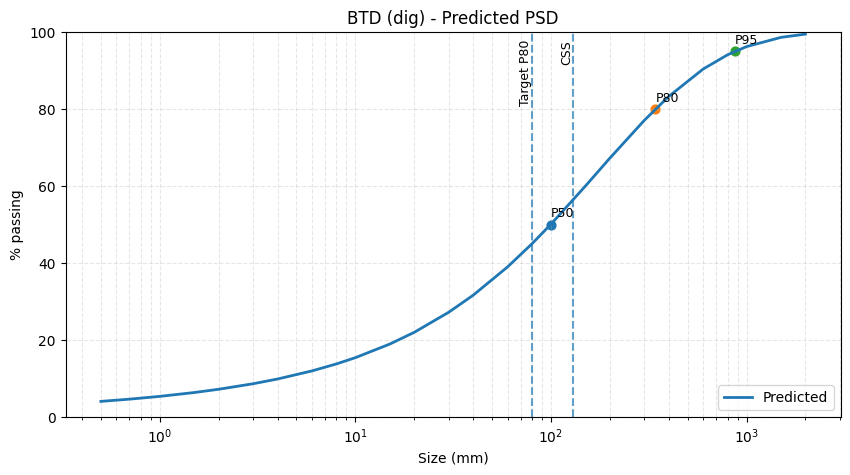

CRUSH inferred model: PsdParam(model='swebrec_xmax', params={'x50_mm': 99.528, 'b': 3.5, 'xmax_mm': 2500.0})
CRUSH percentiles: {'p20': 20.775707999469304, 'p50': 99.52799999999996, 'p80': 285.6363134250005, 'p95': 622.749809177539, 'p98': 865.8793785045948}


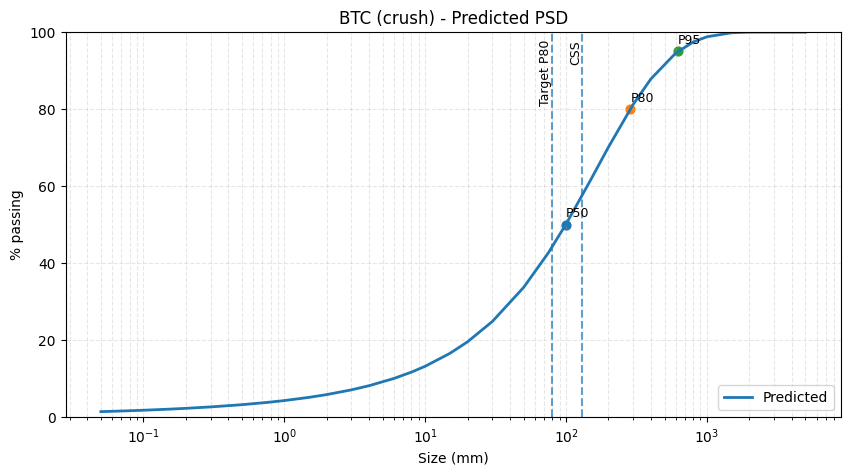

In [9]:
# --- Example: run inference + evaluation for BTD (dig) and BTC (crush)

design = DesignInputs(
	burden_m=7.0,
	spacing_m=8.0,
	bench_height_m=10.0,
	hole_diameter_mm=165.0,
	stemming_m=3.0,
	subdrill_m=1.0,
	ucs_mpa=110.0,
	explosive_density_gcc=1.15,
	explosive_energy_mjkg=3.2,
	pattern="staggered",
)

# Infer model for DIG (BTD)
model_dig, dbg_dig = infer_swebrec_xmax(design, "dig")
res_dig = evaluate_psd(
	context="dig",
	design=design,
	mode="modelled",
	model=model_dig,
	x_grid_mm=DEFAULT_X_GRID_MM,
	sample_sizes_mm=DEFAULT_SAMPLE_SIZES_MM,
)

print("DIG inferred model:", model_dig)
print("DIG percentiles:", res_dig["percentiles_mm"])
plot_psd(
	res_dig,
	title="BTD (dig) - Predicted PSD",
	css_mm=DEFAULTS_UI["css_mm"],
	target_p80_mm=DEFAULTS_UI["target_p80_mm"],
	x_max_cap_mm=2000.0,
	markers=DEFAULT_MARKERS,
	focus_mode_id="auto",
)

# Infer model for CRUSH (BTC)
model_crush, dbg_crush = infer_swebrec_xmax(design, "crush")
res_crush = evaluate_psd(
	context="crush",
	design=design,
	mode="modelled",
	model=model_crush,
	x_grid_mm=DEFAULT_X_GRID_MM_CRUSH,
	sample_sizes_mm=DEFAULT_SAMPLE_SIZES_MM,
)

print("CRUSH inferred model:", model_crush)
print("CRUSH percentiles:", res_crush["percentiles_mm"])
plot_psd(
	res_crush,
	title="BTC (crush) - Predicted PSD",
	css_mm=DEFAULTS_UI["css_mm"],
	target_p80_mm=DEFAULTS_UI["target_p80_mm"],
	x_max_cap_mm=5000.0,
	markers=DEFAULT_MARKERS,
	focus_mode_id="auto",
)


In [10]:
# --- Load measured PSD data (template)

def measured_from_cdf_pairs(df: pd.DataFrame, size_col: str, passing_col: str) -> PsdDiscreteCdfPairs:
	"""passing_col can be 0..1 or 0..100 (auto-scaled)."""
	x = df[size_col].astype(float).to_list()
	y = df[passing_col].astype(float).to_list()
	y_max = np.nanmax(y) if len(y) else 1.0
	if y_max > 1.5:
		y = [float(v)/100.0 for v in y]
	return PsdDiscreteCdfPairs(type="cdf_pairs", x_mm=x, passing_frac=y)

def compare_model_vs_measured(
	*,
	context: PsdContext,
	design: DesignInputs,
	model: PsdParam,
	measured: PsdDiscrete,
	x_grid_mm: List[float],
) -> pd.DataFrame:
	pred = evaluate_psd(context=context, design=design, mode="modelled", model=model, x_grid_mm=x_grid_mm)
	meas = evaluate_psd(context=context, design=design, mode="measured", measured=measured, x_grid_mm=x_grid_mm)

	# align on same x grid
	px = np.asarray(pred["series"][0]["x"], dtype=float)
	py = np.asarray(pred["series"][0]["y"], dtype=float)
	mx = np.asarray(meas["series"][0]["x"], dtype=float)
	my = np.asarray(meas["series"][0]["y"], dtype=float)

	df = pd.DataFrame({"x_mm": px, "pred_pct": py, "meas_pct": my})
	df["resid_pct"] = df["pred_pct"] - df["meas_pct"]
	df["abs_resid_pct"] = df["resid_pct"].abs()
	return df, pred, meas



In [11]:
file_path="frag/Shovel 119 (Metric) 2024 Daily-copy.xlsx"
df=pd.read_excel(file_path, sheet_name="Sheet1")
df["TimeStamp Site TZ"]=pd.to_datetime(df["TimeStamp Site TZ"], errors="coerce")

# Drop rows missing key SWB percentiles
mask = df["P50 SWB (mm)"].notna() & df["P80 SWB (mm)"].notna() & df["P20 SWB (mm)"].notna()
d=df.loc[mask].copy()

# Basic stats
def qstats(s):
	s=pd.to_numeric(s, errors="coerce").dropna()
	return pd.Series({
		"n": len(s),
		"mean": float(s.mean()),
		"p10": float(s.quantile(0.10)),
		"p50": float(s.quantile(0.50)),
		"p90": float(s.quantile(0.90)),
	})

summary = pd.DataFrame({
	"P20_SWB_mm": qstats(d["P20 SWB (mm)"]),
	"P50_SWB_mm": qstats(d["P50 SWB (mm)"]),
	"P80_SWB_mm": qstats(d["P80 SWB (mm)"]),
	"SWB_b": qstats(d["SWB b"]),
	"SWB_x50_mm": qstats(d["SWB x50 (mm)"]),
	"SWB_xMax_mm": qstats(d["SWB xMax (mm)"]),
	"lt10_SWB_pct": qstats(d["< 10 mm SWB (%)"]),
	"lt25_SWB_pct": qstats(d["< 25 mm SWB (%)"]),
	"P80_RR_mm": qstats(d["P80 RR (mm)"]),
	"RR_n": qstats(d["RR n"]),
	"RR_Xc_mm": qstats(d["RR Xc (mm)"]),
}).T

summary

,n,mean,p10,p50,p90
P20_SWB_mm,133.0,84.706767,60.200000,74.000000,128.600000
P50_SWB_mm,133.0,187.263158,151.000000,187.000000,216.000000
P80_SWB_mm,133.0,354.691729,273.200000,371.000000,419.800000
SWB_b,133.0,5.954412,4.214595,5.195487,10.000000
SWB_x50_mm,133.0,187.262194,151.250810,186.747146,216.140384
SWB_xMax_mm,133.0,3320.961248,2307.679127,3243.721777,4499.999871
lt10_SWB_pct,133.0,2.526316,0.000000,3.000000,4.000000
lt25_SWB_pct,133.0,5.684211,0.000000,7.000000,9.000000
P80_RR_mm,133.0,378.736842,305.800000,388.000000,430.600000
RR_n,133.0,1.222142,1.061624,1.165874,1.415173


In [12]:
# Define baseline Connectors inferred params when ratios=1 (reference design), for dig and crush.
def connectors_baseline_params(context: str):
	x50_ref=65.0; b_ref=4.3; xmax_ref=5000.0
	x50=x50_ref; b=b_ref; xmax=max(xmax_ref, 22.0*x50)
	# apply context clamps
	if context=="crush":
		x50=min(max(x50,20.0),250.0)
		b=min(max(b,1.3),3.5)
		xmax=min(max(xmax,300.0),2500.0)
	else:
		x50=min(max(x50,10.0),600.0)
		b=min(max(b,1.2),8.0)
		xmax=min(max(xmax,200.0),10000.0)
	return x50,b,xmax

# Median site-calibrated params using FRAGTrack SWB outputs
site_x50=float(summary.loc["SWB_x50_mm","p50"])
site_b=float(summary.loc["SWB_b","p50"])
site_xmax=float(summary.loc["SWB_xMax_mm","p50"])

baseline_dig=connectors_baseline_params("dig")
baseline_crush=connectors_baseline_params("crush")
baseline_dig, baseline_crush, (site_x50,site_b,site_xmax)



((65.0, 4.3, 5000.0),
 (65.0, 3.5, 2500.0),
 (186.7471459549432, 5.195487468698015, 3243.7217769163485))

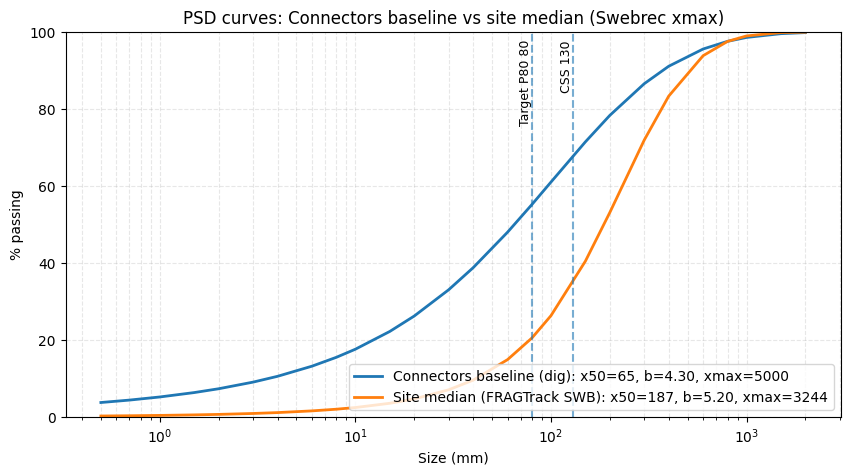

In [13]:
# Build overlay plot: baseline dig vs calibrated median SWB curve
def cdf_swebrec_xmax(x, x50, b, xmax):
	x=np.asarray(x,dtype=float)
	out=np.zeros_like(x)
	out[x>=xmax]=1.0
	mask=(x>0)&(x<xmax)&(x50>0)&(b>0)&(xmax>0)&(x50<xmax)
	if not np.any(mask):
		return np.clip(out,0,1)
	den=np.log(xmax/x50)
	num=np.log(xmax/x[mask])
	ratio=num/den
	out[mask]=1.0/(1.0+np.power(ratio,b))
	return np.clip(out,0,1)

# x grid as per dig default
x_grid=np.array([
  0.5, 0.7, 1, 1.5, 2, 3, 4, 6, 8, 10,
  15, 20, 30, 40, 60, 80, 100, 150, 200, 300,
  400, 600, 800, 1000, 1500, 2000
], dtype=float)

def curve_pct(x50,b,xmax):
	return 100*cdf_swebrec_xmax(x_grid,x50,b,xmax)

bd=baseline_dig
bc=baseline_crush
y_baseline=curve_pct(*bd)
y_site=curve_pct(site_x50, site_b, site_xmax)

plt.figure(figsize=(10,5))
plt.plot(x_grid, y_baseline, linewidth=2, label=f"Connectors baseline (dig): x50={bd[0]:.0f}, b={bd[1]:.2f}, xmax={bd[2]:.0f}")
plt.plot(x_grid, y_site, linewidth=2, label=f"Site median (FRAGTrack SWB): x50={site_x50:.0f}, b={site_b:.2f}, xmax={site_xmax:.0f}")
plt.xscale("log")
plt.ylim(0,100)
plt.xlabel("Size (mm)")
plt.ylabel("% passing")
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.axvline(130, linestyle="--", alpha=0.6)
plt.text(130, 98, "CSS 130", rotation=90, va="top", ha="right", fontsize=9)
plt.axvline(80, linestyle="--", alpha=0.6)
plt.text(80, 98, "Target P80 80", rotation=90, va="top", ha="right", fontsize=9)
plt.legend(loc="lower right")
plt.title("PSD curves: Connectors baseline vs site median (Swebrec xmax)")
plt.show()



In [14]:
# Compute per-record residuals: baseline vs measured SWB percentiles
def percentiles_from_params(x50,b,xmax):
	# approximate inverse by searching over log grid + interpolate
	# Use brute bisection as earlier but faster: use our own bisection with vectorized CDF
	def quant(p):
		lo=0.1; hi=min(max(xmax, 10.0), 10000.0)
		for _ in range(60):
			mid=0.5*(lo+hi)
			if float(cdf_swebrec_xmax(np.array([mid]), x50,b,xmax)[0]) < p:
				lo=mid
			else:
				hi=mid
		return 0.5*(lo+hi)
	return {"p20":quant(0.2),"p50":quant(0.5),"p80":quant(0.8),"p95":quant(0.95)}

baseline_params={"x50":bd[0],"b":bd[1],"xmax":bd[2]}
cal_params={"x50":site_x50,"b":site_b,"xmax":site_xmax}

rows=[]
for _,r in d.iterrows():
	meas={"p20":float(r["P20 SWB (mm)"]), "p50":float(r["P50 SWB (mm)"]), "p80":float(r["P80 SWB (mm)"])}
	# predicted percentiles from baseline and calibrated
	pred_base=percentiles_from_params(**baseline_params)
	pred_cal=percentiles_from_params(**cal_params)
	rows.append({
		"date": r["TimeStamp Site TZ"],
		"meas_p20": meas["p20"],
		"meas_p50": meas["p50"],
		"meas_p80": meas["p80"],
		"base_p20": pred_base["p20"],
		"base_p50": pred_base["p50"],
		"base_p80": pred_base["p80"],
		"cal_p20": pred_cal["p20"],
		"cal_p50": pred_cal["p50"],
		"cal_p80": pred_cal["p80"],
	})
comp=pd.DataFrame(rows)
# errors
for p in ["p20","p50","p80"]:
	comp[f"err_base_{p}_mm"]=comp[f"base_{p}"]-comp[f"meas_{p}"]
	comp[f"err_cal_{p}_mm"]=comp[f"cal_{p}"]-comp[f"meas_{p}"]

err_summary=pd.DataFrame({
	"baseline_MAE_mm": [comp[[f"err_base_{p}_mm" for p in ["p20","p50","p80"]]].abs().mean().mean()],
	"baseline_MBE_mm": [comp[[f"err_base_{p}_mm" for p in ["p20","p50","p80"]]].mean().mean()],
	"calibrated_MAE_mm":[comp[[f"err_cal_{p}_mm" for p in ["p20","p50","p80"]]].abs().mean().mean()],
	"calibrated_MBE_mm":[comp[[f"err_cal_{p}_mm" for p in ["p20","p50","p80"]]].mean().mean()],
})
err_summary



,baseline_MAE_mm,baseline_MBE_mm,calibrated_MAE_mm,calibrated_MBE_mm
0,111.82553,-111.360681,30.230103,0.836934


In [15]:
# Show percentile-specific MAE
detail=pd.DataFrame({
	"MAE_base_mm":[comp["err_base_p20_mm"].abs().mean(), comp["err_base_p50_mm"].abs().mean(), comp["err_base_p80_mm"].abs().mean()],
	"MAE_cal_mm":[comp["err_cal_p20_mm"].abs().mean(), comp["err_cal_p50_mm"].abs().mean(), comp["err_cal_p80_mm"].abs().mean()],
}, index=["P20","P50","P80"])
detail

,MAE_base_mm,MAE_cal_mm
P20,72.250054,20.135744
P50,122.263158,21.152277
P80,140.963379,49.402289


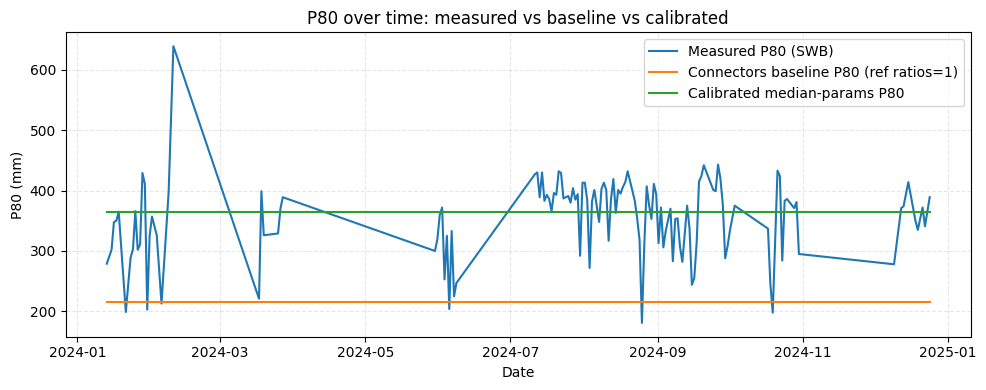

In [16]:
# Plot time series of measured P80 vs baseline predicted P80 and calibrated predicted P80
plt.figure(figsize=(10,4))
plt.plot(comp["date"], comp["meas_p80"], label="Measured P80 (SWB)")
plt.plot(comp["date"], comp["base_p80"], label="Connectors baseline P80 (ref ratios=1)")
plt.plot(comp["date"], comp["cal_p80"], label="Calibrated median-params P80")
plt.ylabel("P80 (mm)")
plt.xlabel("Date")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.title("P80 over time: measured vs baseline vs calibrated")
plt.tight_layout()
plt.show()

In [17]:
# Save calibrated coefficients recommendation for Connectors infer-model, along with summary stats and notes.
calibration_reco = {
	"site": "Shovel 119 (FRAGTrack 2024 daily)",
	"recommended_swebrec_xmax": {
		"x50_mm_p50": site_x50,
		"b_p50": site_b,
		"xmax_mm_p50": site_xmax,
		"x50_mm_p10": float(summary.loc["SWB_x50_mm","p10"]),
		"x50_mm_p90": float(summary.loc["SWB_x50_mm","p90"]),
		"b_p10": float(summary.loc["SWB_b","p10"]),
		"b_p90": float(summary.loc["SWB_b","p90"]),
		"xmax_mm_p10": float(summary.loc["SWB_xMax_mm","p10"]),
		"xmax_mm_p90": float(summary.loc["SWB_xMax_mm","p90"]),
	},
	"notes": [
		"These are empirical fitted parameters reported by FRAGTrack (SWB columns).",
		"To map into Connectors infer-model, use these as site-calibrated anchors/priors for swebrec_xmax, then re-introduce dependence on PF/EF/UCS once blast design data is joined."
	]
}

out_csv="frag/fragtrack_shovel119_2024_summary.csv"
summary.to_csv(out_csv)

out_params="frag/fragtrack_shovel119_2024_site_calibration.json"

with open(out_params,"w",encoding="utf-8") as f:
	json.dump(calibration_reco,f,indent=2)

out_csv, out_params



('frag/fragtrack_shovel119_2024_summary.csv',
 'frag/fragtrack_shovel119_2024_site_calibration.json')

In [18]:
# --- Customer PSD priors (site-calibrated anchors from FRAGTrack SWB medians)

CUSTOMER_PSD_PRIORS = {
	"name": "Customer: Shovel 119 (FRAGTrack 2024 daily)",
	# Site medians (SWB)
	"x50_ref_mm": 186.7471459549432,
	"b_ref": 5.195487468698015,
	"xmax_ref_mm": 3243.7217769163485,

	"ef_ref_mj_m3": 2.5,
}

# Original defaults from Connectors backend:
CONNECTORS_DEFAULT_PRIORS = {
	"name": "Connectors default",
	"x50_ref_mm": 65.0,
	"b_ref": 4.3,
	"xmax_ref_mm": 5000.0,
	"ef_ref_mj_m3": 2.5,
}


In [19]:
def infer_swebrec_xmax_with_priors(
	d: DesignInputs,
	context: PsdContext,
	priors: dict,
) -> tuple[PsdParam, dict]:
	pf = _powder_factor_kg_m3(d)
	ef = _energy_factor_mj_m3(d, pf)

	# ---- anchors from priors (site-calibrated or defaults)
	x50_ref = float(priors["x50_ref_mm"])
	b_ref = float(priors["b_ref"])
	xmax_ref = float(priors["xmax_ref_mm"])
	ef_ref = float(priors.get("ef_ref_mj_m3", 2.5))

	burden = float(d.burden_m)
	spacing = float(d.spacing_m)
	ucs = float(d.ucs_mpa)

	br = burden / 7.0 if burden > 0 else 1.0
	sr = spacing / 8.0 if spacing > 0 else 1.0
	ur = ucs / 110.0 if ucs > 0 else 1.0
	er = (ef / ef_ref) if (ef is not None and ef > 0) else 1.0

	# ---- exponents as current Connectors infer-model
	x50 = x50_ref * (br**0.45) * (sr**0.25) * (ur**0.40) * (er**-0.65)
	b = b_ref * (er**0.22) * (ur**-0.12)
	xmax = max(xmax_ref * (ur**0.12) * (er**-0.08), 22.0 * x50)

	# ---- context clamps
	if context == "crush":
		x50 = _clamp(x50, 20.0, 250.0)
		b = _clamp(b, 1.3, 3.5)
		xmax = _clamp(xmax, 300.0, 2500.0)
	else:
		x50 = _clamp(x50, 10.0, 600.0)
		b = _clamp(b, 1.2, 8.0)
		xmax = _clamp(xmax, 200.0, 10000.0)

	model = PsdParam(
		model="swebrec_xmax",
		params={"x50_mm": float(round(x50, 3)), "b": float(round(b, 3)), "xmax_mm": float(round(xmax, 3))},
	)

	debug = {
		"pf_kg_m3": None if pf is None else float(round(pf, 4)),
		"ef_mj_m3": None if ef is None else float(round(ef, 2)),
		"priors": dict(priors),
		"ratios": {"br": br, "sr": sr, "ur": ur, "er": er},
	}
	return model, debug


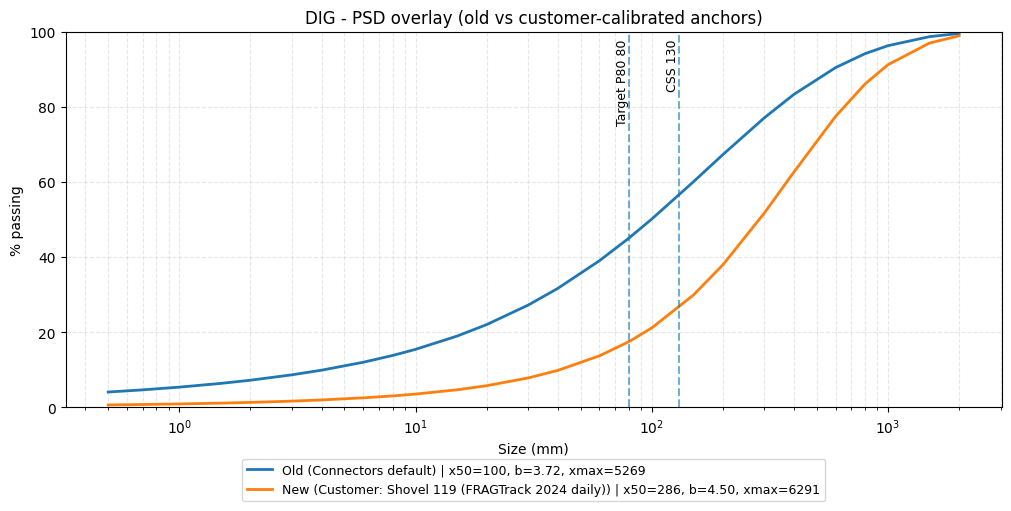

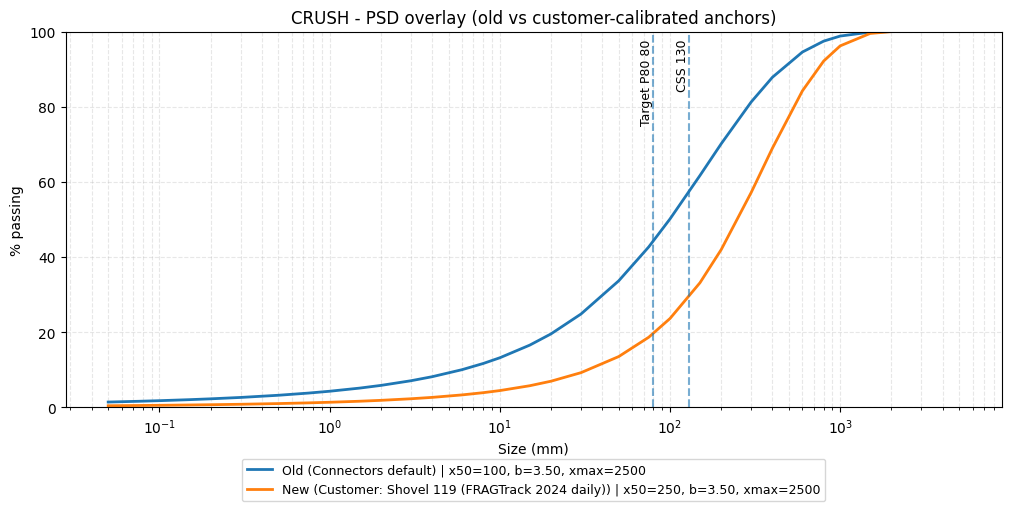

In [20]:
# Example design
design = DesignInputs(
	burden_m=7.0,
	spacing_m=8.0,
	bench_height_m=10.0,
	hole_diameter_mm=165.0,
	stemming_m=3.0,
	subdrill_m=1.0,
	ucs_mpa=110.0,
	explosive_density_gcc=1.15,
	explosive_energy_mjkg=3.2,
	pattern="staggered",
)

def plot_old_vs_new(context: PsdContext):
	# Infer old/default
	m_old, dbg_old = infer_swebrec_xmax_with_priors(design, context, CONNECTORS_DEFAULT_PRIORS)
	r_old = evaluate_psd(
		context=context,
		design=design,
		mode="modelled",
		model=m_old,
		x_grid_mm=DEFAULT_X_GRID_MM_CRUSH if context == "crush" else DEFAULT_X_GRID_MM,
	)

	# Infer new/customer
	m_new, dbg_new = infer_swebrec_xmax_with_priors(design, context, CUSTOMER_PSD_PRIORS)
	r_new = evaluate_psd(
		context=context,
		design=design,
		mode="modelled",
		model=m_new,
		x_grid_mm=DEFAULT_X_GRID_MM_CRUSH if context == "crush" else DEFAULT_X_GRID_MM,
	)

	# Plot overlay (single axis)
	fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

	x_old = np.array(r_old["series"][0]["x"], dtype=float)
	y_old = np.array(r_old["series"][0]["y"], dtype=float)
	ax.plot(
		x_old, y_old, linewidth=2,
		label=f'Old ({CONNECTORS_DEFAULT_PRIORS["name"]}) | x50={m_old.params["x50_mm"]:.0f}, b={m_old.params["b"]:.2f}, xmax={m_old.params["xmax_mm"]:.0f}'
	)

	x_new = np.array(r_new["series"][0]["x"], dtype=float)
	y_new = np.array(r_new["series"][0]["y"], dtype=float)
	ax.plot(
		x_new, y_new, linewidth=2,
		label=f'New ({CUSTOMER_PSD_PRIORS["name"]}) | x50={m_new.params["x50_mm"]:.0f}, b={m_new.params["b"]:.2f}, xmax={m_new.params["xmax_mm"]:.0f}'
	)

	ax.set_xscale("log")
	ax.set_ylim(0, 100)
	ax.set_xlabel("Size (mm)")
	ax.set_ylabel("% passing")
	ax.grid(True, which="both", linestyle="--", alpha=0.3)

	# UI reference lines
	ax.axvline(130, linestyle="--", alpha=0.6)
	ax.text(130, 98, "CSS 130", rotation=90, va="top", ha="right", fontsize=9)

	ax.axvline(80, linestyle="--", alpha=0.6)
	ax.text(80, 98, "Target P80 80", rotation=90, va="top", ha="right", fontsize=9)

	ax.set_title(f"{context.upper()} - PSD overlay (old vs customer-calibrated anchors)")

	ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1, frameon=True, fontsize=9)

	plt.show()


	return (m_old, m_new, r_old, r_new)

# Run both contexts
old_dig, new_dig, res_old_dig, res_new_dig = plot_old_vs_new("dig")
old_crush, new_crush, res_old_crush, res_new_crush = plot_old_vs_new("crush")
